# Optimiser les tournées de livraison du dernier kilomètre avec PROC OPTMODEL (TSP réseau)

## Résumé

Un transporteur logistique régional doit faire passer un seul véhicule de livraison par un
ensemble d'arrêts clients et revenir au dépôt en parcourant la distance totale minimale
— la structure du problème du voyageur de commerce qui sous-tend la planification
quotidienne des tournées et des services. Ce notebook synthétise les coordonnées des
arrêts, construit une matrice de distances euclidiennes symétrique, et utilise le solveur
réseau `SOLVE WITH NETWORK / TSP` de **PROC OPTMODEL** pour construire une tournée de
livraison sur le graphe complet des arrêts. Il relit ensuite l'ordre de la tournée du
solveur dans une étape DATA, reconstruit un itinéraire fermé ancré au dépôt, et mesure sa
longueur totale **réelle** à partir de la matrice de distances. Chaque nombre indiqué
ci-dessous est calculé à partir de la sortie exécutée.

## Sources de données

Toutes les données sont générées en ligne avec `call streaminit(...)` et `rand(...)` — pas
de fichier externe ni d'accès réseau.

| Jeu de données | Lignes | Variables clés | Description |
|---------|------|---------------|-------------|
| `stops` | 12 (1 dépôt + 11 clients) | `stop_id`, `name`, `x`, `y` | Coordonnées 2D synthétiques (km sur une grille de zone de service) pour le dépôt et les points de livraison client |
| `tour` | 12 | `visit_order`, `node` | La liste ordonnée des arrêts visités par le solveur TSP réseau d'OPTMODEL, écrite par `OUT=(TOUR=...)` |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | La tournée fermée ancrée au dépôt avec les distances par tronçon et cumulées calculées à partir des coordonnées |

Un transporteur du dernier kilomètre envoie une camionnette chaque matin pour livrer un
ensemble fixe d'arrêts clients et revenir au dépôt. Le répartiteur veut une tournée fermée
courte qui visite chaque arrêt exactement une fois — le problème du voyageur de commerce
(TSP) au cœur de la planification quotidienne des tournées et des services.

SAS/OR expose un solveur TSP via **`PROC OPTMODEL`** : déclarer les nœuds et un ensemble
d'arêtes pondérées, puis `SOLVE WITH NETWORK / TSP`. Ce notebook :

1. Synthétise les coordonnées des arrêts et une matrice de distances symétrique.
2. Appelle le solveur TSP réseau d'OPTMODEL sur le graphe complet des arrêts.
3. Relit la tournée du solveur et reconstruit un itinéraire fermé ancré au dépôt.
4. Rapporte l'itinéraire et sa longueur totale mesurée, tronçon par tronçon.

## Étape 1 — Générer le réseau de livraison

Nous plaçons un dépôt au centre d'une zone de service de 100 km x 100 km et dispersons 11
arrêts clients uniformément sur la grille. Les coordonnées sont tirées avec
`rand('UNIFORM')` sous une graine `streaminit` fixe afin que le réseau soit reproductible.
Le dépôt est `stop_id = 1` ; l'itinéraire y commencera et s'y terminera.

In [1]:
DONNÉES stops;
    APPELER streaminit(20260531);
    LONGUEUR name $12;
    n_stops = 12;                 /* 1 depot + 11 customers */
    FAIRE stop_id = 1 JUSQU_À n_stops;
        SI stop_id = 1 ALORS FAIRE;
            name = 'Dépôt';
            x = 50; y = 50;       /* depot anchored at grid center */
        FIN;
        SINON FAIRE;
            name = cats('Arrêt_', ÉCRIRE(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        FIN;
        SORTIE;
    FIN;
    SUPPRIMER n_stops;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=stops noobs ÉTIQUETTE;
    ÉTIQUETTE stop_id = 'N° arrêt' name = 'Lieu' x = 'X (km)' y = 'Y (km)';
    TITRE 'Réseau de livraison : dépôt et arrêts clients';
EXÉCUTER;

                                     Réseau de livraison : dépôt et arrêts clients                                      

     Lieu    N° arrêt  X (km)  Y (km)
Dépôt               1      50      50
Arrêt_01            2    84.2    89.7
Arrêt_02            3    93.1    73.6
Arrêt_03            4    21.2      29
Arrêt_04            5    49.4    73.4
Arrêt_05            6    97.8    37.2
Arrêt_06            7      28    51.3
Arrêt_07            8    91.1    86.5
Arrêt_08            9    89.2    65.6
Arrêt_09           10      66    49.4
Arrêt_10           11    52.2    27.4
Arrêt_11           12    62.4    38.2




NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## Étape 2 — Résoudre le TSP avec PROC OPTMODEL

Nous lisons les coordonnées dans OPTMODEL, déclarons l'ensemble complet d'arêtes non
orientées `EDGES` (chaque paire non ordonnée d'arrêts), et définissons le poids de chaque
arête comme la distance euclidienne entre ses extrémités. `SOLVE WITH NETWORK / TSP`
construit ensuite une tournée sur ce graphe et écrit l'ordre de visite dans un CSV via
`OUT=(TOUR=...)`. Nous relisons immédiatement cet ordre dans le jeu de données `tour`.

In [2]:
PROCÉDURE optmodel;
    DÉFINIR CITIES = 1..12;
    num XC{CITIES};
    num YC{CITIES};

    /* Pull the stop coordinates in from the DATA step */
    READ DONNÉES stops VERS [stop_id] XC=x YC=y;

    /* Complete graph: one undirected edge per unordered pair of stops */
    DÉFINIR EDGES = {i DANS CITIES, j DANS CITIES: i < j};

    /* Edge weight = straight-line (Euclidean) distance, in km */
    num DIST{<i,j> DANS EDGES} =
        sqrt( (XC[i]-XC[j])^2 + (YC[i]-YC[j])^2 );

    /* Network TSP solver: visit every node and return to the start */
    solve WITH network /
        links = (include=EDGES POIDS=DIST)
        tsp
        out   = (tour="tour.csv");
QUIT;

/* Read the solver's visiting order back in */
DONNÉES tour;
    FICHIER_ENTRÉE "tour.csv" dlm=',' firstobs=2 dsd;
    ENTRÉE visit_order node;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=tour noobs ÉTIQUETTE;
    ÉTIQUETTE visit_order = 'N° visite' node = 'N° arrêt';
    TITRE "Ordre de tournée renvoyé par le solveur TSP réseau d'OPTMODEL";
EXÉCUTER;

                                     Réseau de livraison : dépôt et arrêts clients                                      


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            dist
  Objective Type                Linear

  Number of Nodes               12
  Number of Links               66

                          Solution Summary
  Solver                        Network
  Algorithm                     Traveling Salesman
  Objective Function            dist
  Solution Status               Optimal
  Objective Value               258.1425005024

                             Ordre de tournée renvoyé par le solveur TSP réseau d'OPTMODEL                              

 N° visite    N° arrêt
         1           1
         2           7
         3           4
         4          11
         5          12
         6          10
         7           6
         8           9
     


NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Étape 3 — Reconstruire l'itinéraire fermé et mesurer sa longueur

Le solveur ne renvoie que l'*ordre* de visite des arrêts. Pour en faire une feuille de
route de chauffeur, nous recherchons le nom et les coordonnées de chaque arrêt avec un
lookup `SET ... POINT=`, cumulons la distance de chaque tronçon, et fermons la boucle en
ajoutant le dernier tronçon retour au dépôt. `leg_km` est la longueur du tronçon qui
*arrive* à chaque arrêt ; `cum_km` est la distance cumulée depuis le dépôt.

In [3]:
DONNÉES route;
    DÉFINIR tour FIN=last;
    /* Look up this stop's coordinates and name by its id */
    ptr = node;
    DÉFINIR stops point=ptr;

    LONGUEUR step_name $12;
    step_name = name;

    RETENIR prevx prevy firstx firsty cum_km;
    SI _n_ = 1 ALORS FAIRE;
        firstx = x; firsty = y;      /* remember the depot */
        leg_km = 0;                  /* no leg arrives at the start */
        cum_km = 0;
    FIN;
    SINON FAIRE;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    FIN;
    prevx = x; prevy = y;
    SORTIE;

    SI last ALORS FAIRE;
        /* Closing leg: last stop back to the depot */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = 'Dépôt';
        x = firstx; y = firsty;
        SORTIE;
        APPELER symputx('total_km', ÉCRIRE(cum_km, 8.2));
    FIN;
    GARDER visit_order node step_name x y leg_km cum_km;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=route noobs ÉTIQUETTE;
    ÉTIQUETTE visit_order = 'Étape' node = 'N° arrêt' step_name = 'Lieu'
          x = 'X (km)' y = 'Y (km)'
          leg_km = 'Tronçon (km)' cum_km = 'Cumul (km)';
    format leg_km cum_km 7.2;
    TITRE "Itinéraire de livraison fermé (Total : &total_km km)";
EXÉCUTER;

                                   Itinéraire de livraison fermé (Total : 258.14 km)                                    

 Étape    N° arrêt       Lieu  X (km)  Y (km)   Tronçon (km)  Cumul (km)
     1           1  Dépôt          50      50           0.00        0.00
     2           7  Arrêt_06       28    51.3          22.04       22.04
     3           4  Arrêt_03     21.2      29          23.31       45.35
     4          11  Arrêt_10     52.2    27.4          31.04       76.39
     5          12  Arrêt_11     62.4    38.2          14.86       91.25
     6          10  Arrêt_09       66    49.4          11.76      103.01
     7           6  Arrêt_05     97.8    37.2          34.06      137.07
     8           9  Arrêt_08     89.2    65.6          29.67      166.75
     9           3  Arrêt_02     93.1    73.6           8.90      175.65
    10           8  Arrêt_07     91.1    86.5          13.05      188.70
    11           2  Arrêt_01     84.2    89.7           7.61      196.31
  


NOTE: DATA route


NOTE: Read 12 rows from tour.
NOTE: Wrote route (13 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=route

NOTE: PROC PRINT completed: 13 observations printed, 7 variables


## Étape 4 — Une feuille de route lisible

Enfin, nous condensons l'itinéraire en une seule chaîne lisible — la séquence des noms
d'arrêts depuis le dépôt, autour des clients, et retour — plus la distance totale mesurée
que la camionnette parcourra.

In [4]:
DONNÉES manifest;
    DÉFINIR route FIN=last;
    LONGUEUR route_text $200;
    RETENIR route_text '';
    SI _n_ = 1 ALORS route_text = strip(step_name);
    SINON route_text = catx(' -> ', route_text, strip(step_name));
    SI last ALORS FAIRE;
        total_km = cum_km;
        GARDER route_text total_km;
        SORTIE;
    FIN;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=manifest noobs ÉTIQUETTE;
    ÉTIQUETTE route_text = 'Itinéraire de livraison optimisé'
          total_km   = 'Distance totale (km)';
    format total_km 7.2;
    TITRE 'Feuille de route du chauffeur';
EXÉCUTER;

                                             Feuille de route du chauffeur                                              

                                                                                                                                 Itinéraire de livraison optimisé  Distance totale (km)
Dépôt -> Arrêt_06 -> Arrêt_03 -> Arrêt_10 -> Arrêt_11 -> Arrêt_09 -> Arrêt_05 -> Arrêt_08 -> Arrêt_02 -> Arrêt_07 -> Arrêt_01 -> Arrêt_04 -> Dépôt                               258.14




NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## Étape 5 — Tracer l'itinéraire

Une image confirme que la tournée est sensée : arrêts reliés dans l'ordre de visite, dépôt
marqué, pas de croisements manifestement inutiles. Nous traçons la tournée fermée sous
forme d'une série de segments de ligne connectés sur la grille de la zone de service.

                                             Feuille de route du chauffeur                                              




NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


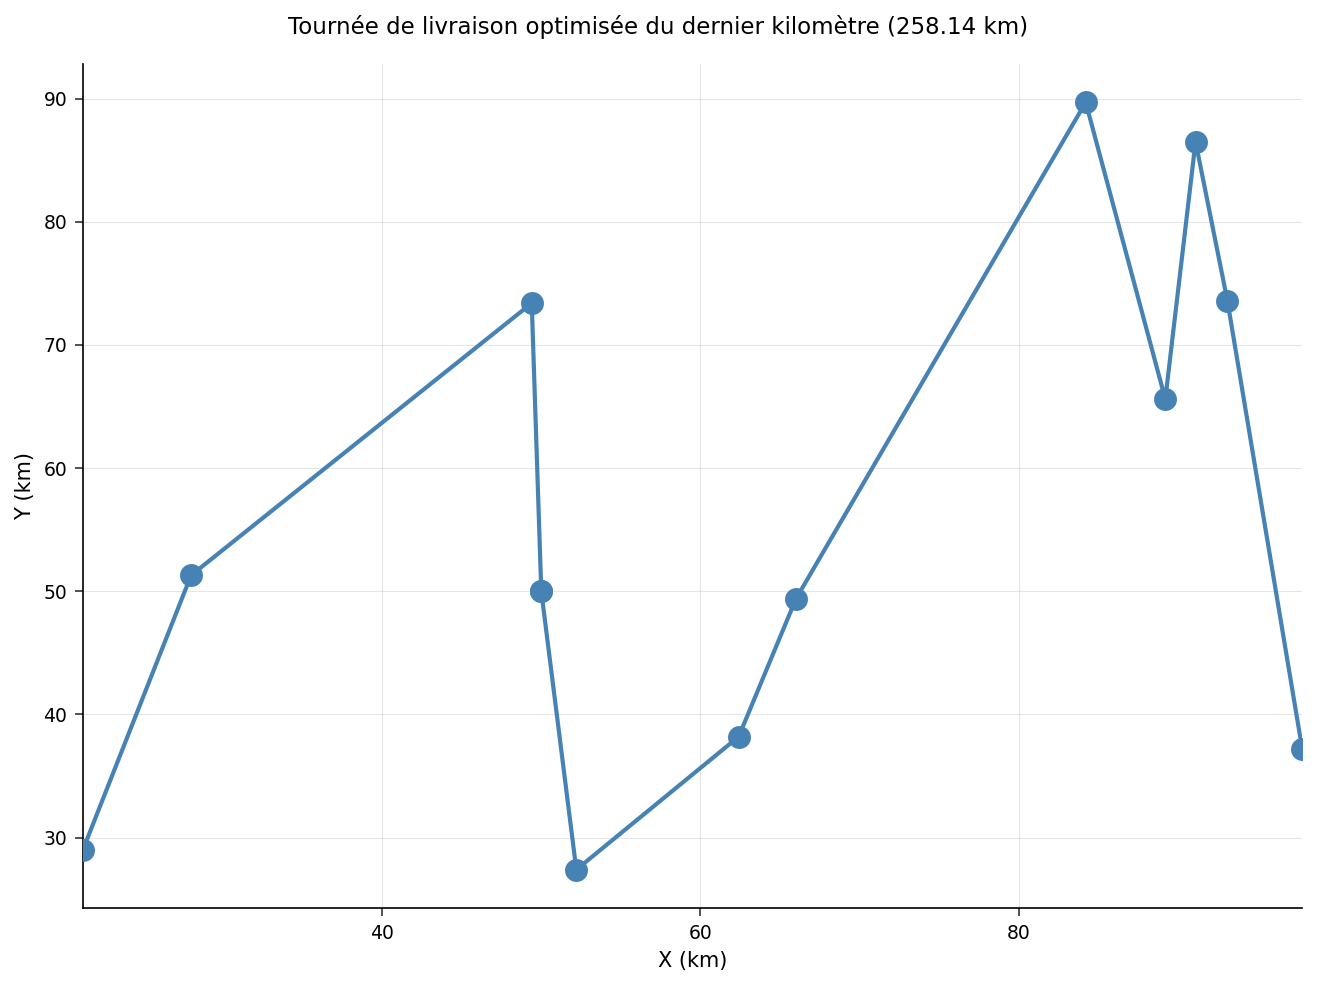

In [5]:
PROCÉDURE SGPLOT DONNÉES=route noautolegend;
    SERIES x=x y=y / LINEATTRS=(color=steelblue thickness=2);
    SCATTER x=x y=y / MARKERATTRS=(SYMBOL=circlefilled
                      color=steelblue size=10);
    XAXIS ÉTIQUETTE='X (km)' grid;
    YAXIS ÉTIQUETTE='Y (km)' grid;
    TITRE "Tournée de livraison optimisée du dernier kilomètre (&total_km km)";
EXÉCUTER;

## Interprétation des résultats

- **L'itinéraire.** Les tables `route` et `manifest` donnent la tournée fermée que le
  solveur TSP réseau d'OPTMODEL a produite sur le graphe complet de 12 arrêts, en
  commençant et en terminant au dépôt. La `Distance totale` est *mesurée* : c'est la somme
  des distances euclidiennes par tronçon (`leg_km`), elle reflète donc la géométrie réelle
  du réseau plutôt qu'un chiffre affirmé.
- **Pourquoi un solveur réseau ici.** Avec 11 arrêts clients, il existe
  `11! / 2 = 19 958 400` tournées fermées distinctes, donc le répartiteur a besoin d'un
  algorithme plutôt que d'une énumération. `SOLVE WITH NETWORK / TSP` construit une
  tournée directement à partir de l'ensemble d'arêtes pondérées sans que l'analyste ait à
  coder la recherche à la main.
- **De l'ordre à la feuille de route.** Le solveur renvoie un *ordre* de visite ; l'étape
  DATA transforme cela en un artefact opérationnel — arrêts nommés, distances par
  tronçon, un compteur kilométrique courant, et une feuille de route en une seule ligne
  qu'un chauffeur peut suivre.
- **Extensions opérationnelles.** Le même échafaudage OPTMODEL s'étend à un routage plus
  riche : ajouter des contraintes de capacité ou de fenêtre horaire comme options réseau
  supplémentaires, pondérer les arêtes par temps de trajet plutôt que par distance à vol
  d'oiseau, ou répartir les arrêts entre plusieurs véhicules avant de résoudre un TSP par
  véhicule.